In [1]:
import sys
sys.path.append("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/utils") 
os.chdir("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro")
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import matplotlib.pyplot as plt
# from utils.custom import plotting

In [2]:
# East River
ER_RESULT_PATH = "/scratch/dlhogan/ess-project-data/calibration/bestruns/East_River_baseline_1981_2025/run/out/baseline_timestep.nc"


In [3]:
aso_flight_20180331 = rxr.open_rasterio("/scratch/dlhogan/ess-project-data/geospatial-data/ASO/East/ASO_50M_SWE_USCOGE_20190407.tif", masked=True).squeeze()

east_shapefile = gpd.read_file("/scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/shapefiles/catchment/East_River_distributed_elevAspect_HRUs_elevation_aspect.shp")

result = xr.open_dataset(ER_RESULT_PATH)

In [4]:
# mask aso
# average aso swe by hru 
aso_swe_by_hru = east_shapefile.set_index('HRU_ID').geometry.apply(lambda geom: aso_flight_20180331.rio.clip([geom], east_shapefile.crs).mean().item())*1000

# result swe for same time as aso flight
result_swe = result['scalarSWE'].resample(time='1D').mean().sel(time='2019-04-07').to_pandas()


In [5]:
# add to east shapefile
east_shapefile['ASO_SWE'] = east_shapefile['HRU_ID'].map(aso_swe_by_hru)
east_shapefile['SUMMA_SWE'] = east_shapefile['HRU_ID'].map(result_swe)

Text(0.5, 1.0, 'SUMMA - ASO SWE on 2018-05-24')

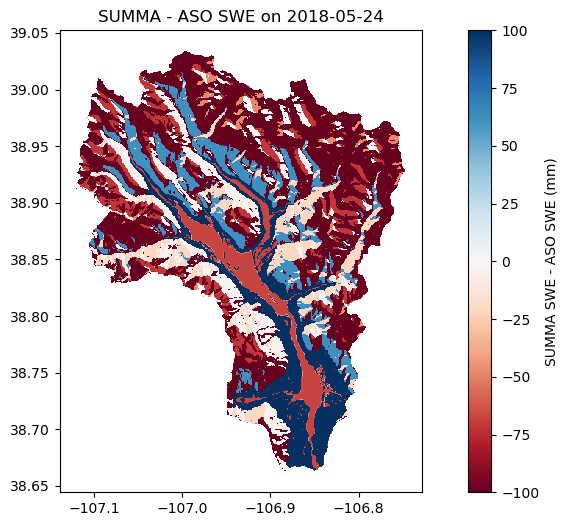

In [6]:
# plot map of aso swe and result swe by hru
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
east_shapefile.plot(column=result_swe-aso_swe_by_hru, ax=ax, legend=True, vmin=-100, vmax=100, cmap='RdBu', 
                    # add cmap label
                    legend_kwds={'label': "SUMMA SWE - ASO SWE (mm)"})
ax.set_title('SUMMA - ASO SWE on 2018-05-24')
# east_shapefile.plot(column=(result_swe), ax=ax[1], legend=True, vmin=0, vmax=500, cmap='Blues')
# ax[1].set_title('SUMMA SWE on 2018-03-31')


---

# Systematic SWE bias: all ASO flights vs SUMMA

Extends the single-flight prototype above to every usable flight, to separate a **uniform**
bias from one organized by **elevation** or **aspect**.

**Flight screening.** 15 rasters are present; 12 are used.

| dropped | why |
|---|---|
| `ASO_50M_SWE_USCOGT_20190408` | Gunnison–**Taylor** tile — 0% overlap with the East River HRUs |
| `ASO_EastRiver_20260318`, `..._20260405` | after the model record ends (baseline runs to 2025-12-31) |

The remaining 12 cover **all 18 HRUs at ≥99%**, and pair naturally into an early
(Mar–Apr) and a late (May–Jun) flight in each of 2018, 2019, 2022, 2023, 2024, 2025.

**Two data quirks handled in the loader.** ASO SWE is in **metres** (×1000 → mm). One file,
`ASO_50M_SWE_USCOGE_20190407`, carries 387 artifact pixels up to 728 m and encodes its
off-footprint area as `0` rather than `NaN` unlike every other file — so values above
`SWE_MAX_M` are dropped. Per-HRU coverage is checked against the pixel count implied by
`HRU_area`, *not* against the polygon bounding box: these HRUs are elevation×aspect
*classes*, spatially fragmented across the whole basin, so their bounding boxes are nearly
basin-sized and a bbox-based check reports ~5% for flights that actually cover 99%.

In [1]:
import glob, os, re, warnings
from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd, xarray as xr
import rasterio
from rasterio.mask import mask as rio_mask
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
warnings.filterwarnings("ignore")

DATA_ROOT = Path("/scratch/dlhogan/ess-project-data")
FIGDIR = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft")

# one entry per basin; add another basin here and every figure below picks it up
ASO_BASINS = {
    "East": dict(
        aso_dir=DATA_ROOT / "geospatial-data/ASO/East",
        shp=DATA_ROOT / "domain_East_River_distributed_elevAspect/shapefiles/catchment/"
                        "East_River_distributed_elevAspect_HRUs_elevation_aspect.shp",
        result=DATA_ROOT / "calibration/bestruns/East_River_baseline_1981_2025/"
                           "run/out/baseline_timestep.nc"),
    "Tuolumne": dict(
        aso_dir=DATA_ROOT / "geospatial-data/ASO/Tuolumne",
        shp=DATA_ROOT / "domain_Tuolumne_River_distributed_elevAspect/shapefiles/catchment/"
                        "Tuolumne_River_distributed_elevAspect_HRUs_elevation_aspect.shp",
        result=DATA_ROOT / "calibration/bestruns/experiments/Tuolumne_River_baseline_upperW15_1981_2025/"
                           "run/out/baseline_timestep.nc"),
}

SWE_MAX_M = 5.0        # artifact guard (some flights carry pixels up to 728 m)
MIN_COVER = 0.10        # require this fraction of an HRU to have valid pixels
INK, GRAY = "#333", "#dddddd"
ASP_CENTER = {1: 45, 2: 135, 3: 225, 4: 315}
ASP_NAME = {1: "NE", 2: "SE", 3: "SW", 4: "NW"}


def band_edges(means):
    """Radial band edges from band-mean elevations (midpoints; end bands mirrored)."""
    e = {}
    for i in range(len(means)):
        lo = (means[i-1] + means[i]) / 2 if i > 0 else means[i] - (means[i+1] - means[i]) / 2
        hi = (means[i] + means[i+1]) / 2 if i < len(means)-1 else means[i] + (means[i] - means[i-1]) / 2
        e[i] = (lo, hi)
    return e


def load_aso_hru(shp, aso_dir, result_path):
    """Per-HRU ASO SWE (mm) and SUMMA SWE (mm) on the matching date, every usable flight.

    Returns (g, df); df is long-form date / HRU_ID / aso / summa / cover / diff.
    """
    g = gpd.read_file(shp)
    exp_px = g["HRU_area"].values / 2500.0                 # 50 m pixels
    res = xr.open_dataset(result_path)
    swe = res["scalarSWE"].resample(time="1D").mean()
    tmin = pd.Timestamp(swe["time"].values[0]); tmax = pd.Timestamp(swe["time"].values[-1])

    rows = []
    for f in sorted(aso_dir.glob("*.tif"), key=lambda p: re.search(r"(\d{8})", p.name).group(1)):
        date = pd.Timestamp(re.search(r"(\d{8})", f.name).group(1))
        if not (tmin <= date <= tmax):
            print(f"    [skip] {date:%Y-%m-%d}: outside model record"); continue
        with rasterio.open(f) as r:
            gg = g.to_crs(r.crs)
            aso, cov = [], []
            for i, (_, row) in enumerate(gg.iterrows()):
                out, _ = rio_mask(r, [row.geometry], crop=True, filled=True, nodata=np.nan)
                a = out[0].astype(float)
                a[a > SWE_MAX_M] = np.nan
                if r.nodata is not None and not np.isnan(r.nodata):
                    a[a == r.nodata] = np.nan
                n = int((~np.isnan(a)).sum())
                cov.append(min(n / exp_px[i], 1.0))
                aso.append(np.nanmean(a) * 1000.0 if n else np.nan)     # m -> mm
        cov = np.array(cov)
        if np.nanmean(cov) < 0.5:
            print(f"    [skip] {date:%Y-%m-%d}: no basin overlap ({100*np.nanmean(cov):.0f}%)")
            continue
        sim = swe.sel(time=date, method="nearest").to_pandas()
        for i, hid in enumerate(g["HRU_ID"].values):
            rows.append(dict(date=date, HRU_ID=hid, aso=aso[i],
                             summa=float(sim.get(hid, np.nan)), cover=cov[i]))
    res.close()
    df = pd.DataFrame(rows)
    df.loc[df["cover"] < MIN_COVER, ["aso", "summa"]] = np.nan
    # calculate percent bias
    df["diff"] = (df["summa"] - df["aso"]) / df["aso"] * 100
    return g, df


# ---- load every basin once; downstream cells read `aso_results` ----
aso_results = {}
for name, cfg in ASO_BASINS.items():
    if not Path(cfg["result"]).exists():
        print(f"[skip] {name}: baseline run not found ({Path(cfg['result']).name})"); continue
    print(f"=== {name} ===")
    g, df = load_aso_hru(cfg["shp"], cfg["aso_dir"], cfg["result"])
    attr = g.set_index("HRU_ID"); aw = attr["HRU_area"] / attr["HRU_area"].sum()
    d = df.dropna(subset=["aso", "summa"]).copy()
    d["elev"] = d["HRU_ID"].map(attr["elev_mean"]); d["asp"] = d["HRU_ID"].map(attr["aspectClas"])
    d["band"] = d["HRU_ID"].map(attr["elevClass"]); d["w"] = d["HRU_ID"].map(aw)
    aso_results[name] = dict(g=g, d=d)

    wavg = lambda x, c: np.average(x[c], weights=x["w"])
    ta = d.groupby("date").apply(lambda x: wavg(x, "aso"))
    ts = d.groupby("date").apply(lambda x: wavg(x, "summa"))
    print(f"  {d['date'].nunique()} flights x {d['HRU_ID'].nunique()} HRUs = {len(d)} pairs")
    print(f"  overall  ASO {ta.mean():.0f}  SUMMA {ts.mean():.0f}  "
          f"bias {ts.mean()-ta.mean():+.0f} mm ({100*(ts.mean()-ta.mean())/ta.mean():+.1f}%)  "
          f"| SUMMA high on {(ts>ta).sum()}/{len(ta)} flights")
    print("  by elevation band:")
    for b, x in d.groupby("band"):
        print(f"    {wavg(x,'elev'):5.0f} m: ASO {wavg(x,'aso'):5.0f}  SUMMA {wavg(x,'summa'):5.0f}"
              f"  bias {wavg(x,'diff'):+6.0f} mm ({100*wavg(x,'diff')/wavg(x,'aso'):+5.1f}%)")
    print("  by aspect:")
    for a, x in d[d.asp > 0].groupby("asp"):
        print(f"    {ASP_NAME[a]}: ASO {wavg(x,'aso'):5.0f}  SUMMA {wavg(x,'summa'):5.0f}"
              f"  bias {wavg(x,'diff'):+6.0f} mm ({100*wavg(x,'diff')/wavg(x,'aso'):+5.1f}%)")
    print()

=== East ===
    [skip] 2019-04-08: no basin overlap (0%)
    [skip] 2026-03-18: outside model record
    [skip] 2026-04-05: outside model record
  12 flights x 18 HRUs = 216 pairs
  overall  ASO 290  SUMMA 273  bias -17 mm (-5.9%)  | SUMMA high on 5/12 flights
  by elevation band:
     2686 m: ASO    71  SUMMA    93  bias    -32 mm (-44.7%)
     3012 m: ASO   187  SUMMA   218  bias    +24 mm (+12.9%)
     3361 m: ASO   441  SUMMA   358  bias    -21 mm ( -4.8%)
     3709 m: ASO   605  SUMMA   540  bias    -13 mm ( -2.2%)
  by aspect:
    NE: ASO   370  SUMMA   322  bias     +1 mm ( +0.2%)
    SE: ASO   314  SUMMA   262  bias    -28 mm ( -8.8%)
    SW: ASO   262  SUMMA   272  bias     +4 mm ( +1.6%)
    NW: ASO   291  SUMMA   299  bias    +15 mm ( +5.0%)

=== Tuolumne ===
    [skip] 2026-04-06: outside model record
  50 flights x 28 HRUs = 1400 pairs
  overall  ASO 323  SUMMA 303  bias -20 mm (-6.2%)  | SUMMA high on 16/50 flights
  by elevation band:
     1590 m: ASO     9  SUMMA    20

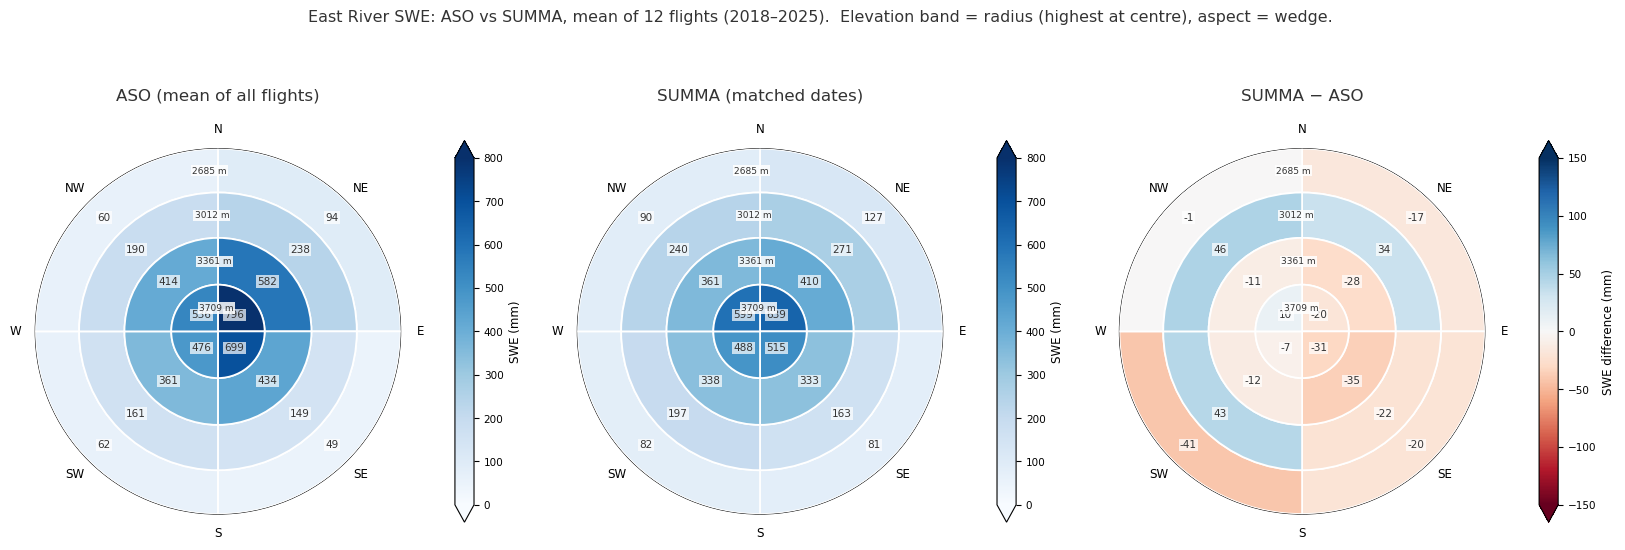

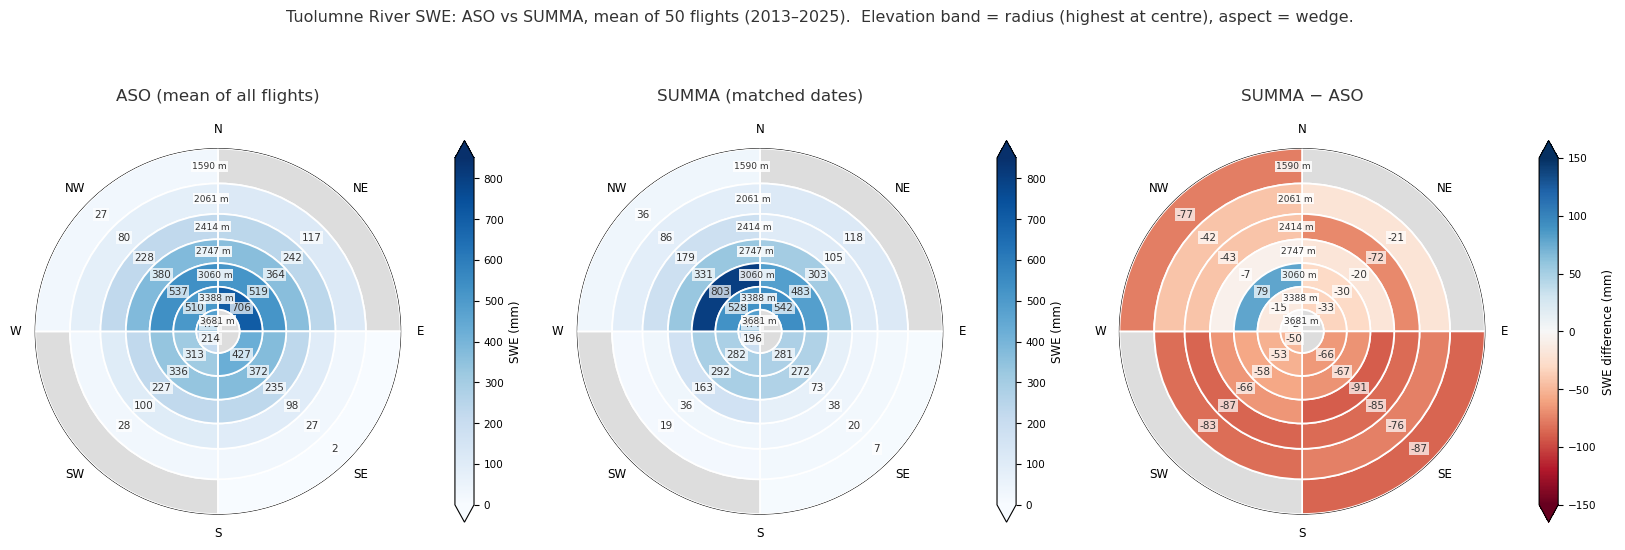

In [11]:
# ---- mean / mean / difference on the elevation x aspect radial, one figure per basin ----
def cellv(gg, band, asp, col):
    s = gg[(gg.elevClass == band) & (gg.aspectClas == asp)]
    if s.empty or s[col].isna().all():
        return np.nan
    return float(np.nansum(s[col] * s["HRU_area"]) / np.nansum(s["HRU_area"]))


def radial(ax, gg, col, cmap, norm):
    bands = sorted(gg.loc[gg.aspectClas > 0, "elevClass"].unique())
    means = np.array([np.average(gg.loc[gg.elevClass == b, "elev_mean"],
                                 weights=gg.loc[gg.elevClass == b, "HRU_area"]) for b in bands])
    e = band_edges(means); ehi = max(h for _, h in e.values()); elo = min(l for l, _ in e.values())
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    for bi, b in enumerate(bands):
        lo, hi = e[bi]
        for c in (1, 2, 3, 4):
            v = cellv(gg, b, c, col)
            ax.bar(np.deg2rad(ASP_CENTER[c]), hi - lo, width=np.deg2rad(90), bottom=ehi - hi,
                   color=plt.get_cmap(cmap)(norm(v)) if np.isfinite(v) else GRAY,
                   edgecolor="white", linewidth=1.3, zorder=3, align="center")
            if np.isfinite(v):
                ax.text(np.deg2rad(ASP_CENTER[c]), ehi - (lo + hi) / 2, f"{v:.0f}",
                        ha="center", va="center", fontsize=7.5, color=INK, zorder=7,
                        bbox=dict(fc="white", ec="none", alpha=0.7, pad=1.0))
    ax.set_rlim(0, ehi - elo); ax.set_yticklabels([]); ax.grid(False)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"], fontsize=8.5)
    for bi, mm in enumerate(means):
        lo, hi = e[bi]
        ax.text(np.deg2rad(-3), ehi - (lo + hi) / 2, f"{int(mm)} m", ha="center", va="center",
                fontsize=6.5, color=INK, zorder=8,
                bbox=dict(fc="white", ec="none", alpha=0.85, pad=0.8))


def round_up(x, step=50):
    return int(np.ceil(x / step) * step)


for name, R in aso_results.items():
    g, d = R["g"].copy(), R["d"]
    d = d[np.abs(d["diff"]<500)]
    m = d.groupby("HRU_ID")[["aso", "summa", "diff"]].mean()
    for c in ("aso", "summa", "diff"):
        g[c] = g["HRU_ID"].map(m[c])
    # per-basin colour ranges from the plotted cell values (East ~600, Tuolumne ~1500 mm)
    cells = [cellv(g, b, a, c) for b in g.elevClass.unique() for a in (1, 2, 3, 4)
             for c in ("aso", "summa")]
    swe_hi = round_up(np.nanmax(cells), 50)
    dcells = [cellv(g, b, a, "diff") for b in g.elevClass.unique() for a in (1, 2, 3, 4)]
    # diff_lim = round_up(np.nanmax(np.abs(dcells)), 25)

    fig = plt.figure(figsize=(16.5, 5.9))
    panels = [("aso",   "ASO (mean of all flights)", "Blues",  Normalize(0, swe_hi), "SWE (mm)"),
              ("summa", "SUMMA (matched dates)",     "Blues",  Normalize(0, swe_hi), "SWE (mm)"),
              ("diff",  "SUMMA − ASO",               "RdBu",   Normalize(-150, 150),
               "SWE difference (mm)")]
    for i, (col, ttl, cmap, norm, lab) in enumerate(panels):
        ax = fig.add_subplot(1, 3, i + 1, projection="polar")
        radial(ax, g, col, cmap, norm)
        ax.set_title(ttl, fontsize=12, pad=16, color=INK)
        sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
        cb = fig.colorbar(sm, ax=ax, pad=0.11, shrink=0.72, extend="both")
        cb.set_label(lab, fontsize=8.5); cb.ax.tick_params(labelsize=7.5)
    fig.suptitle(f"{name} River SWE: ASO vs SUMMA, mean of {d['date'].nunique()} flights "
                 f"({d['date'].min():%Y}–{d['date'].max():%Y}).  "
                 "Elevation band = radius (highest at centre), aspect = wedge.",
                 fontsize=11.5, y=1.02, color=INK)
    fig.tight_layout()
    fig.savefig(FIGDIR / f"aso_summa_radial_{name}.png", dpi=130, bbox_inches="tight",
                facecolor="white")
    plt.show()

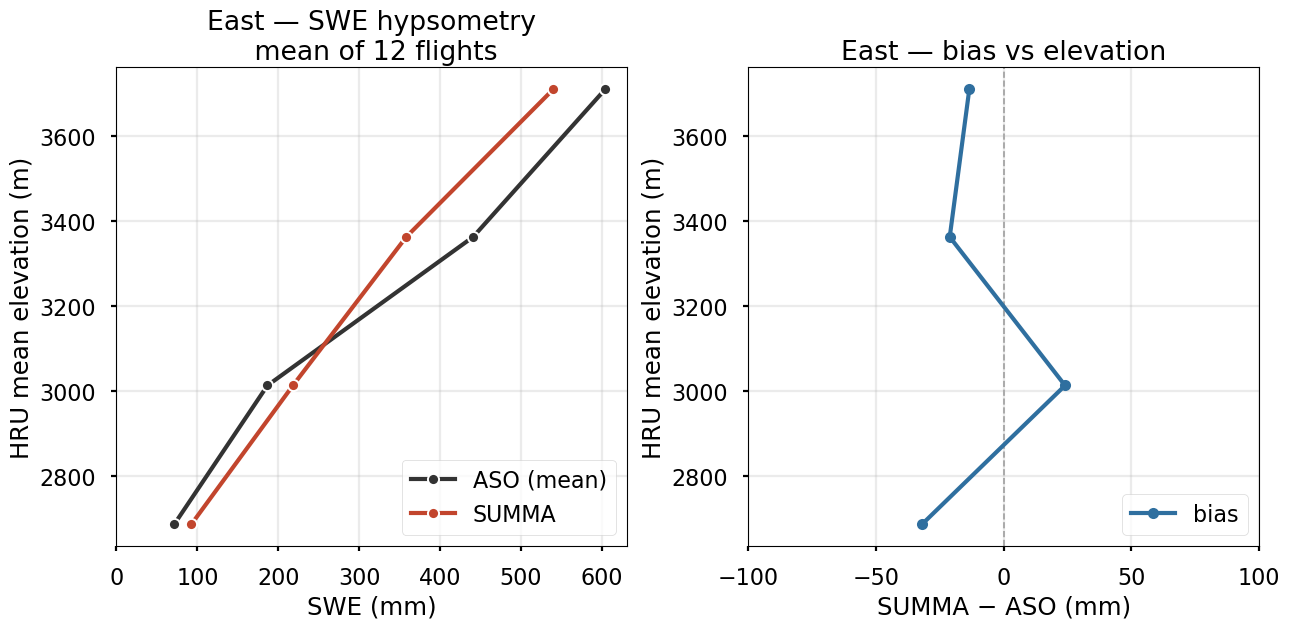

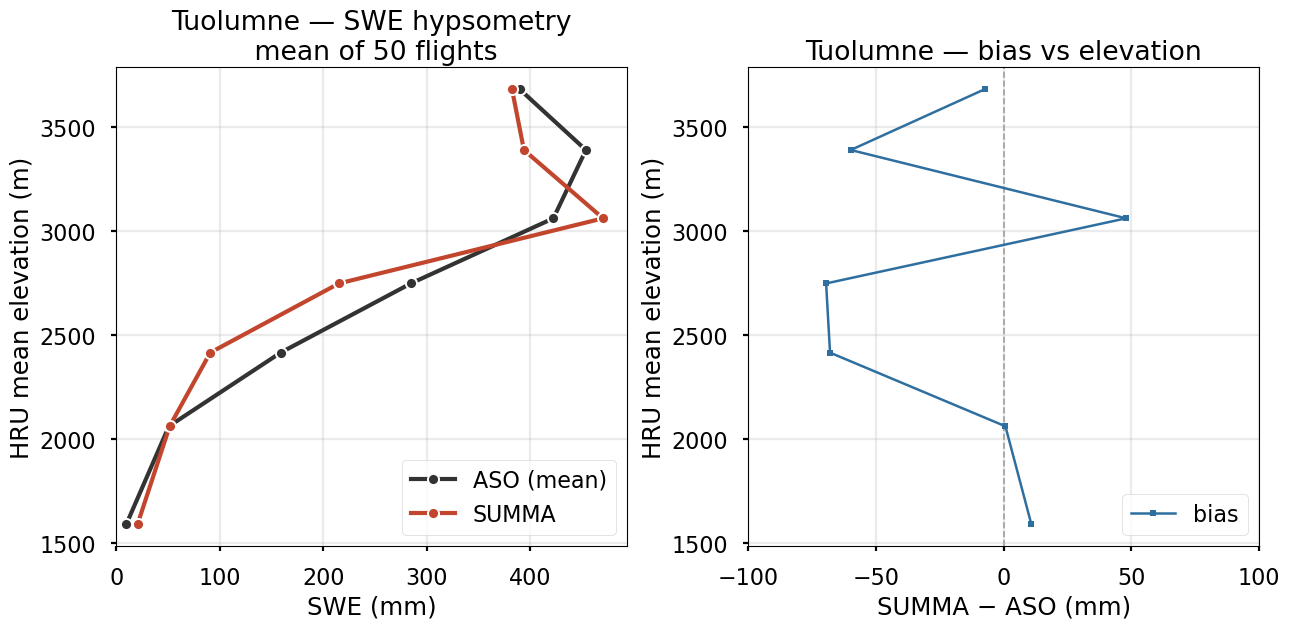

In [21]:
# ---- hypsometry: mean of all flights bold, individual flights translucent, per basin ----
# Plus a "what-if" ASO-shape redistribution overlay (Tuolumne only): the alpha shape
# function is a mass-conserving per-elevation-band multiplier applied to PRECIP, so applying
# the alpha0.5 -> alpha_t conversion to the modelled SWE per band is a first-order test of
# what a steeper (0.75) or flatter (0.25) gradient would do -- isolating REDISTRIBUTION
# (shape) from the winter +10% (magnitude). It adds no water, so the basin mean is unchanged.
C_ASO, C_SIM, C_D = "#333333", "#c2452d", "#2f6f9f"
by_band = lambda x: pd.Series({c: np.average(x[c], weights=x["w"])
                               for c in ("aso", "summa", "diff")})

# ASO SWE / area-weighted basin mean, per elevClass (Tuolumne); area-wt mean = 1.00
ASO_SHAPE_F = {2: 0.1258, 3: 0.2997, 4: 0.7105, 5: 1.1055, 6: 1.1836, 7: 0.9758, 8: 0.6351}
def alpha_conv(band, alpha, base=0.5):
    """f_blend(alpha)/f_blend(base) for a band -> multiplier to reshape SWE from base alpha."""
    f = ASO_SHAPE_F.get(band)
    return None if f is None else (alpha*f + (1-alpha)) / (base*f + (1-base))

ALPHA_OVERLAY = [(0.5, "#1b9e77", "flatter")]
plt.style.use("seaborn-v0_8-poster")
for name, R in aso_results.items():
    d = R["d"]
    band_z = d.groupby("band").apply(lambda x: np.average(x["elev"], weights=x["w"]))

    fig, ax = plt.subplots(1, 2, figsize=(13, 6.4))
    # for dt, x in d.groupby("date"):                      # individual flights
    #     b = x.groupby("band").apply(by_band)
    #     b["z"] = band_z.reindex(b.index); 
    #     b = b.sort_values("z")
    #     # set any subzero values to 0 
    #     b.loc[b["aso"] < 0, "aso"] = 0
    #     ax[0].plot(b["aso"], b["z"], color=C_ASO, lw=1.0, alpha=0.22, zorder=2)
    #     ax[0].plot(b["summa"], b["z"], color=C_SIM, lw=1.0, alpha=0.22, zorder=2)
    #     ax[1].plot(b["diff"], b["z"], color=C_D, lw=1.0, alpha=0.24, zorder=2)

    mb = d.groupby("band").apply(by_band)
    mb["z"] = band_z.reindex(mb.index); mb = mb.sort_values("z")
    ax[0].plot(mb["aso"], mb["z"], color=C_ASO, lw=3, marker="o", ms=8, mec="white", mew=1.4,
               zorder=5, label="ASO (mean)")
    ax[0].plot(mb["summa"], mb["z"], color=C_SIM, lw=3, marker="o", ms=8, mec="white", mew=1.4,
               zorder=5, label="SUMMA")
    ax[0].set_xlim(left=0); 

    # alpha redistribution overlays -- only for basins with a shape function
    if all(alpha_conv(b, 0.5) is not None for b in mb.index):
        for alpha, col, tag in ALPHA_OVERLAY:
            conv = np.array([alpha_conv(b, alpha) for b in mb.index])
            swe_a = mb["summa"].values * conv
            ax[1].plot(swe_a - mb["aso"].values, mb["z"], color=C_D, lw=1.8,
                        marker="s", ms=5, zorder=4, label='bias')
    else:
        ax[1].plot(mb["diff"], mb["z"], color=C_D, lw=3, marker="o", ms=8, mec="white",
               zorder=5, label="bias")

    ax[0].set_xlabel("SWE (mm)"); ax[0].set_ylabel("HRU mean elevation (m)")
    ax[0].set_title(f"{name} — SWE hypsometry\n mean of {d['date'].nunique()} flights"
                    )
    ax[0].legend(loc="lower right"); ax[0].grid(alpha=0.25)

    ax[1].axvline(0, color="#999", lw=1.2, ls="--", zorder=1)
    
    ax[1].set_xlabel("SUMMA − ASO (mm)"); ax[1].set_ylabel("HRU mean elevation (m)")
    ax[1].set_title(f"{name} — bias vs elevation",
                    )
    ax[1].legend(loc="lower right"); ax[1].grid(alpha=0.25)

    ax[1].set_xlim(left=-100, right=100)

    fig.tight_layout()
    fig.savefig(FIGDIR / f"aso_summa_hypsometry_{name}.png", dpi=130, bbox_inches="tight",
                facecolor="white")
    plt.show()